## Imports

In [2]:
import os
import cv2
import random
import numpy as np
import pandas as pd

from PIL import Image
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Dataset Paths

In [5]:
DATASET_PATH = "../smartvision_dataset/classification/train"

## Count Class

In [6]:
classes = sorted(os.listdir(DATASET_PATH))

print(f"Total Classes: {len(classes)}")
print(classes)

Total Classes: 26
['airplane', 'bed', 'bench', 'bicycle', 'bird', 'bottle', 'bowl', 'bus', 'cake', 'car', 'cat', 'chair', 'couch', 'cow', 'cup', 'dog', 'elephant', 'horse', 'motorcycle', 'person', 'pizza', 'potted plant', 'stop sign', 'traffic light', 'train', 'truck']


## image per class

In [7]:
class_counts = {}

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    class_counts[cls] = len(os.listdir(cls_path))

class_df = pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Count"]
)

class_df.sort_values(
    by="Count",
    ascending=False,
    inplace=True
)

class_df.head()

,Class,Count
0,airplane,70
1,bed,70
2,bench,70
3,bicycle,70
4,bird,70


## Class Distribution Plot

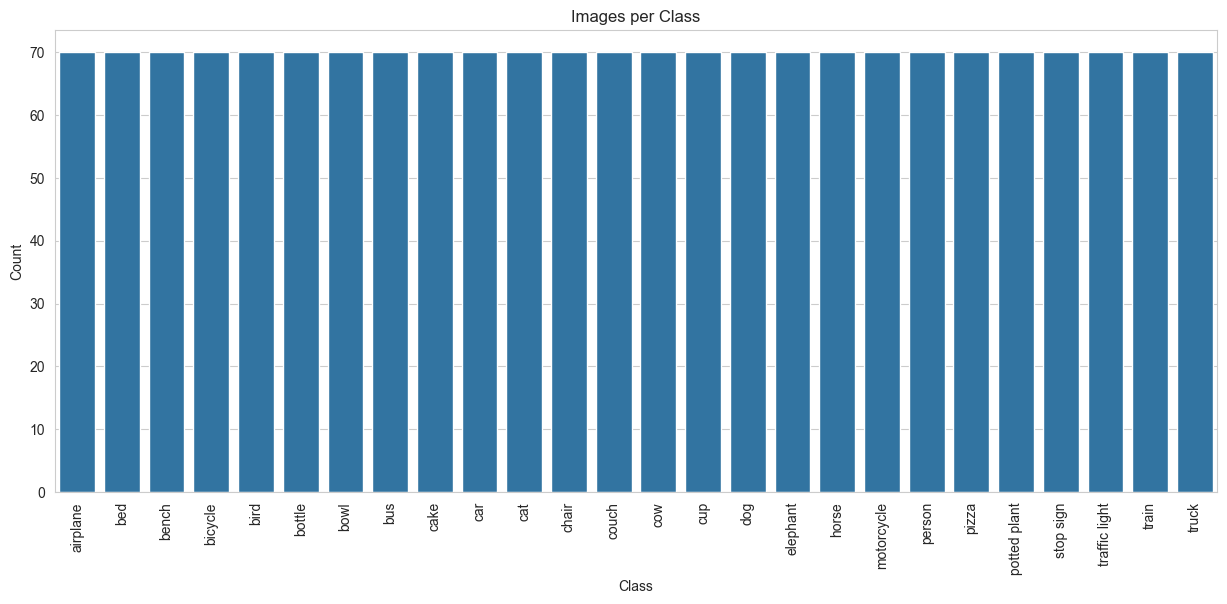

In [8]:
plt.figure(figsize=(15,6))

sns.barplot(
    data=class_df,
    x="Class",
    y="Count"
)

plt.xticks(rotation=90)
plt.title("Images per Class")
plt.show()

## Dataset Summary

In [9]:
print("Total Images :", class_df["Count"].sum())
print("Average Images/Class :", round(class_df["Count"].mean(),2))
print("Min Images/Class :", class_df["Count"].min())
print("Max Images/Class :", class_df["Count"].max())

Total Images : 1820
Average Images/Class : 70.0
Min Images/Class : 70
Max Images/Class : 70


## Image Dimension Analysis

In [10]:
widths = []
heights = []

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)

    for img_name in os.listdir(cls_path):

        img_path = os.path.join(cls_path, img_name)

        try:
            img = Image.open(img_path)

            w,h = img.size

            widths.append(w)
            heights.append(h)

        except:
            pass

## Resolution Distribution

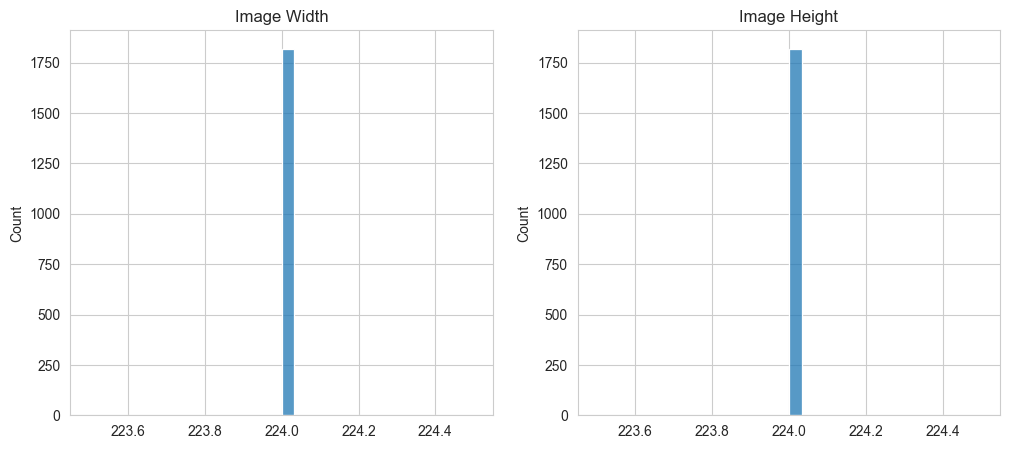

In [11]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(widths, bins=30)

plt.title("Image Width")

plt.subplot(1,2,2)
sns.histplot(heights, bins=30)

plt.title("Image Height")

plt.show()

In [9]:
print("Number of Classes :", len(classes))
print("Training Images :", 1750)
print("Validation Images :", 375)
print("Test Images :", 375)
print("Total Images :", 2500)

Number of Classes : 26
Training Images : 1750
Validation Images : 375
Test Images : 375
Total Images : 2500


## Random Class Samples

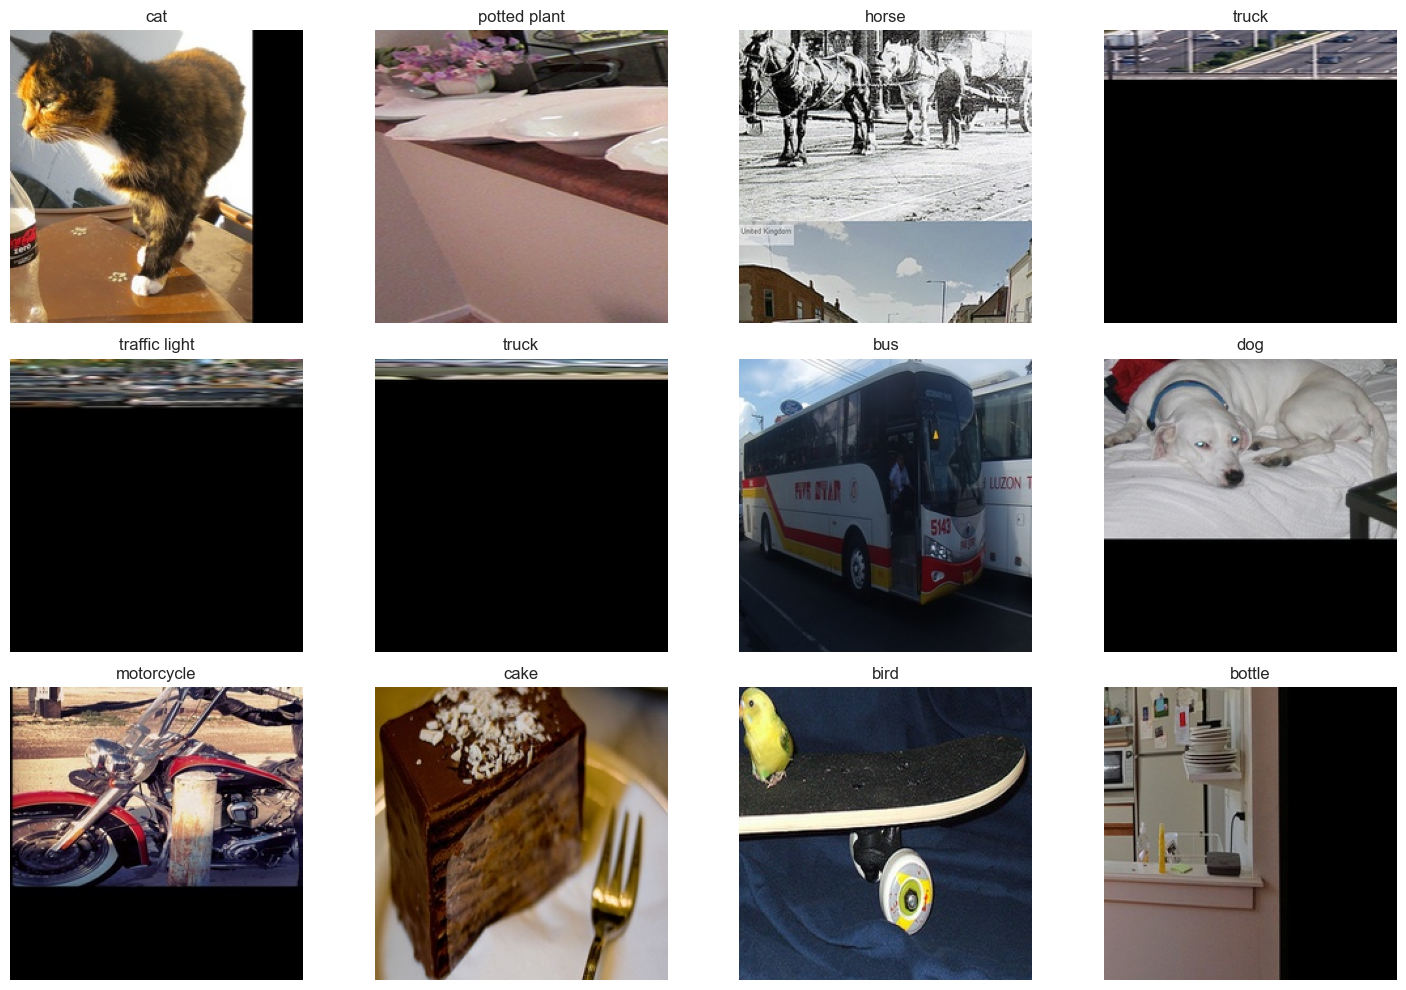

In [12]:
fig, axes = plt.subplots(3,4, figsize=(15,10))

for ax in axes.flat:

    cls = random.choice(classes)

    img_name = random.choice(
        os.listdir(
            os.path.join(DATASET_PATH, cls)
        )
    )

    img_path = os.path.join(
        DATASET_PATH,
        cls,
        img_name
    )

    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
eda_summary = {
    "Total Classes": len(classes),
    "Total Images": class_df["Count"].sum(),
    "Avg Images/Class": class_df["Count"].mean(),
    "Min Images/Class": class_df["Count"].min(),
    "Max Images/Class": class_df["Count"].max()
}

pd.DataFrame([eda_summary])

,Total Classes,Total Images,Avg Images/Class,Min Images/Class,Max Images/Class
0,26,1820,70.0,70,70


In [14]:
print(classes)

['airplane', 'bed', 'bench', 'bicycle', 'bird', 'bottle', 'bowl', 'bus', 'cake', 'car', 'cat', 'chair', 'couch', 'cow', 'cup', 'dog', 'elephant', 'horse', 'motorcycle', 'person', 'pizza', 'potted plant', 'stop sign', 'traffic light', 'train', 'truck']


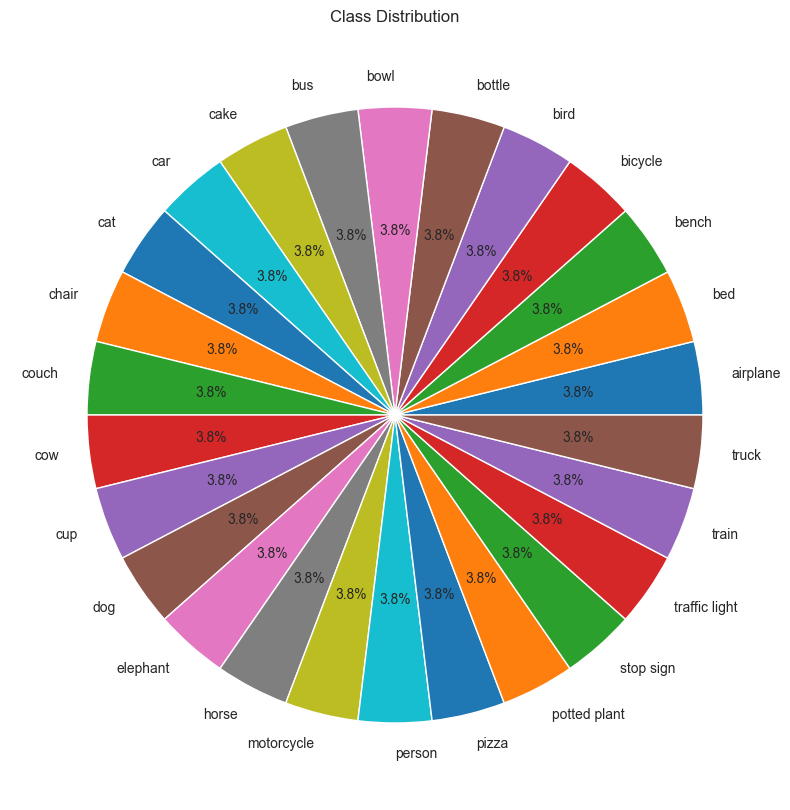

In [15]:
plt.figure(figsize=(10,10))

plt.pie(
    class_df["Count"],
    labels=class_df["Class"],
    autopct='%1.1f%%'
)

plt.title("Class Distribution")
plt.show()

In [16]:
resolution_df = pd.DataFrame({
    "Width": widths,
    "Height": heights
})

resolution_df.describe()

,Width,Height
count,1820.0,1820.0
mean,224.0,224.0
std,0.0,0.0
min,224.0,224.0
25%,224.0,224.0
50%,224.0,224.0
75%,224.0,224.0
max,224.0,224.0


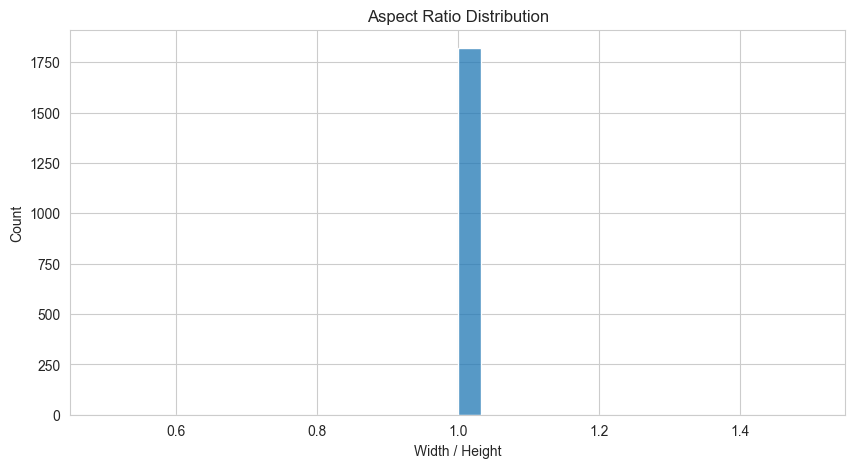

In [17]:
aspect_ratios = np.array(widths) / np.array(heights)

plt.figure(figsize=(10,5))

sns.histplot(aspect_ratios, bins=30)

plt.title("Aspect Ratio Distribution")
plt.xlabel("Width / Height")

plt.show()

In [18]:
image_sizes = []

for cls in classes:

    folder = os.path.join(DATASET_PATH, cls)

    for img_name in os.listdir(folder):

        path = os.path.join(folder, img_name)

        try:
            img = Image.open(path)

            w,h = img.size

            image_sizes.append(
                {
                    "Class": cls,
                    "Width": w,
                    "Height": h,
                    "Pixels": w*h
                }
            )

        except:
            pass

sizes_df = pd.DataFrame(image_sizes)

sizes_df.sort_values(
    by="Pixels",
    ascending=False
).head(15)

,Class,Width,Height,Pixels
1819,truck,224,224,50176
0,airplane,224,224,50176
1,airplane,224,224,50176
2,airplane,224,224,50176
3,airplane,224,224,50176
4,airplane,224,224,50176
5,airplane,224,224,50176
6,airplane,224,224,50176
7,airplane,224,224,50176
8,airplane,224,224,50176


In [19]:
print(len(classes))
print(class_df["Count"].sum())

26
1820
